# Diagnostics for Intersection Asymptotics

This notebook gives some quick diagnostics for the solve quality in the linear system describing the asymptotics of intersection sizes in our model. We noticed that for some parameter settings, especially those corresponding to larger values of $\eta$, the resulting fit looked quite strange and did not agree with simulation data. The hypothesis we investigate is that this is simply an artifact of the eigensolver failing on a challenging matrix, rather than a fundamental issue in our approximation techniques. 

We check this by computing the variance of the vector of relative errors in the numerical leading eigenvalue-eigenvector pair as $\eta$ is increased in a test case, finding that the sharp increase in this quantity corresponds precisely with a decrease in the quality of the fit to data.  

In [53]:
%load_ext autoreload
%autoreload 2
import importlib 
hg = importlib.import_module(".model", "src")

m = importlib.import_module(".analytic-intersection-asymptotics", "src")
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import binom
import xgi
import copy 
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "Lato"

from scipy.sparse.linalg import eigs


from collections import defaultdict, Counter
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

import warnings

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
def intersection_profile(H, update_every = 1, k_max = 12):

    timesteps = len(H.edges)
    r = defaultdict(int)
    
    edge_size_dict = defaultdict(int)
    
    R = np.zeros(shape = (timesteps // update_every + 1, k_max), dtype = int)

    for eid in H.edges:
        
        # get an edge, its size, and its neighborhood
        e = H.edges.members(eid)
        e_size = len(e)
        de = H.edge_neighborhood(eid, prior_only = True, as_node_sets = True)
        
        # update the intersection profile by looping over all neighbors of the 
        # selected edge
        for nb in de:
            nb_size = len(nb)
            k = len(e.intersection(nb))
            r[(e_size, nb_size, k)] += 1
        
        # we also need to update the intersection profile by counting the 
        # number of preceding edges of various sizes that have NO 
        # intersection with the target edge.         
        neighbor_sizes = [len(x) for x in de] # sizes of neighbors
        nb_size_cnt = Counter(neighbor_sizes)
        for j, nj in edge_size_dict.items():
            # number of size j with no intersection is equal to number with
            # size j minus number of neighbors with size j
            r[(j, e_size, 0)] += nj - nb_size_cnt[j] 
        
        # log results in a more summarized format for plotting etc. 
        if eid % update_every == 0:
            for k in range(k_max):
                R[eid//update_every, k] = sum([r[(i, j, k)] for i in range(k_max) for j in range(k_max)])
        edge_size_dict[e_size] += 1
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        R = R / R.sum(axis = 1)[:, None] 
        
    return r, R
        

In [55]:
def diagnostics_experiment(pars, timesteps = int(1e5), show_sim = False, verbose = False, maxiter = None):
    
    
    k_max = len(pars["beta"])
    
    eta, beta, gamma = pars["eta"], pars["beta"], pars["gamma"]
    
    # construct the matrix
    
    # form the approximation infrastructure
    if verbose: 
        print("forming approximating matrix")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        MC = m.MatrixConstructor(k_max, pars)
    M  = MC.matrix_of_linear_map()
    
    if verbose: 
        print(f"   sparsity: {(M == 0).mean():.3f}")
    
    eigval, eigvec = eigs(M, 1, which='LM', maxiter = maxiter)
    eigval = np.real(eigval)
    eigvec = np.real(eigvec)
    if verbose: 
        print(f"   leading eigenvalue = {eigval[0]:.10f}")
    
    # here is the right place to do a test for correctness of the purported eigenvector
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        t = (M@eigvec - eigval*eigvec) / (eigval*eigvec)
        t = np.ma.masked_invalid(t)
    var = np.var(t)
    
    
    if verbose: 
        print(f"   eigenvector test: var = {var:.8f}")
    
    
    if show_sim:
        # construct the hypergraph
        H = hg.GrowingHypergraph()
        H.add_edge((0, 1, 2))
        H.add_edge((3,4))

        if verbose: 
            print("generating hypergraph")
        for cc in range(timesteps): 
            H.sample_edge(eta, beta, gamma, True)
            
        # get the intersection profile
        if verbose: 
            print("computing intersection profile")
            
        r, R = intersection_profile(H, k_max = k_max)
        
        
        
        
        # move on with the approximating tensor
        T  = m.vec_to_tensor(eigvec, k_max)
        
        # construct the visualization
        fig, ax = plt.subplots(1, 1, figsize = (4, 3))

        T_empirical = np.array([[[r[(i, j, k)] for k in range(k_max)] for j in range(k_max)] for i in range(k_max)])
        T_empirical = T_empirical / T_empirical.sum()

        empirical_prop = T_empirical.sum(axis = (0, 1)) / T_empirical.sum()


        empirical_prop = empirical_prop / empirical_prop.sum()

        q    = T.sum(axis = (0,1))
        theory_prop = q.copy()
        theory_prop[1:] = theory_prop[1:] / timesteps 

        theory_prop = theory_prop / theory_prop.sum()
        ix = empirical_prop > 0


        ax.scatter(np.array(range(k_max))[np.where(ix)], empirical_prop[ix], label = "Simulation", edgecolors="cornflowerblue", facecolor = "none", zorder = 10, linewidth=2)
        ax.plot(np.array(range(k_max))[np.where(ix)], theory_prop[ix], label = "Theory", color = "black", linewidth = 1, linestyle = "dashed")
        ax.legend()

        ax.semilogy()
        # ax.xlim(-0.1, 10.5)
        ax.set(xlabel = r"Intersection size $k$", ylabel = r"$r_k$")
        
    
    return var


In [56]:
def quick_case(eta, k_max = 12, timesteps = int(1e4), **kwargs):
    pars = {
        "eta"   : eta, 
        "beta"  : np.zeros(k_max),
        "gamma" : np.zeros(k_max)
    }

    pars["beta"][1:3] = 1/2
    pars["gamma"][0:2] = 1/2
    return diagnostics_experiment(pars, timesteps = timesteps, **kwargs)

In [68]:
ETA = np.linspace(0, 0.5, 21)
V   = np.zeros_like(ETA)

for i, eta in enumerate(ETA):
    V[i] = quick_case(eta)

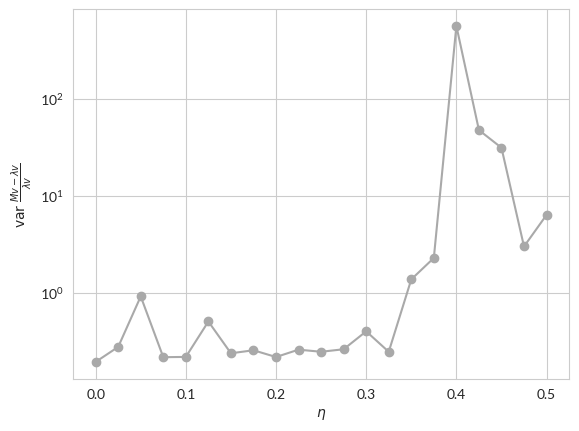

In [70]:
fig, ax = plt.subplots(1, 1)

ax.plot(ETA, V, c = "darkgrey")
ax.scatter(ETA, V, c = "darkgrey")

ax.semilogy()

labs = ax.set(xlabel = r"$\eta$", ylabel = r"$\mathrm{var} \;\frac{Mv - \lambda v}{\lambda v}$")


These results suggest that we should see a degradation in the fit between $\eta = 0.3$ and $\eta = 0.4$, which is confirmed below. These results suggest that approximation failures past $\eta = 0.3$ or so are due to solver issues rather than shortcomings of the proposed approximation scheme. 

# Individual Cases

forming approximating matrix
   sparsity: 0.992
   leading eigenvalue = 1.0000000000
   eigenvector test: var = 0.24992884
generating hypergraph
computing intersection profile


np.float64(0.24992883645803615)

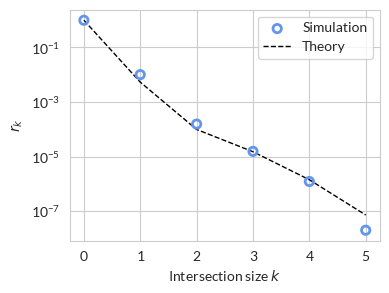

In [48]:
v = quick_case(0.2, verbose = True, show_sim = True)

forming approximating matrix
   sparsity: 0.992
   leading eigenvalue = 0.9999999983
   eigenvector test: var = 0.24426786
generating hypergraph
computing intersection profile


np.float64(0.24426786146352036)

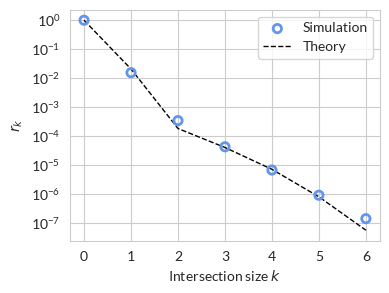

In [51]:
v = quick_case(0.3, verbose = True, show_sim = True)

forming approximating matrix
   sparsity: 0.992
   leading eigenvalue = 1.0678036420
   eigenvector test: var = 0.68510964
generating hypergraph
computing intersection profile


np.float64(0.6851096414010259)

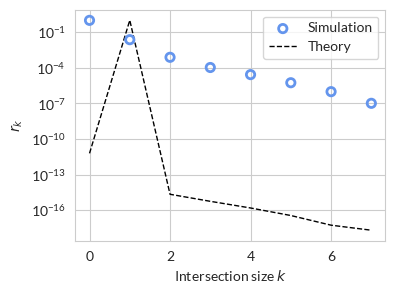

In [52]:
v = quick_case(0.4, verbose = True, show_sim = True)